# Embeddings de Texto

Assim como transformamos imagens em vetores, podemos transformar palavras e textos em vetores numéricos. Neste notebook vamos entender como, por quê, e qual o papel dos tokens nesse processo.

## 1. Transformando Palavras em Vetores

Assim como imagens, palavras podem ser transformadas em vetores numéricos que capturam seu significado.

- sentence-transformers: É a organização que treinou. Eles são focados em criar vetores para frases inteiras (e não só palavras soltas).
- paraphrase: Indica que o modelo foi treinado para entender quando duas frases dizem a mesma coisa, mas com palavras diferentes (perfeito para RAG!).
- multilingual: Funciona em português, inglês, espanhol, etc.
- MiniLM: É um modelo "Mini". Leve

In [1]:
from transformers import AutoTokenizer, AutoModel #biblioteca da Hugging Face
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
from dotenv import load_dotenv
import os

load_dotenv()

# Vamos usar um modelo treinado especificamente para gerar embeddings de texto
nome_modelo = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
# nome_modelo = "pierreguillou/gpt2-small-portuguese"
# nome_modelo = "gpt2"
# nome_modelo = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"
# nome_modelo = "meta-llama/Llama-3.2-1B"
# nome_modelo = "google/gemma-2-2b"

modelo = AutoModel.from_pretrained(nome_modelo)
tokenizador = AutoTokenizer.from_pretrained(nome_modelo)

def texto_para_vetor(texto):

    post_tokenizador = tokenizador(texto, return_tensors="pt") #pt = pytorch
    
    # Passa pelo modelo para gerar o embedding
    with torch.no_grad(): # sem aprender, hein
        saida = modelo(input_ids=post_tokenizador['input_ids'], \
                       attention_mask=post_tokenizador['attention_mask'])
    
    # O modelo retorna um vetor para cada token
    # Pegamos a média para ter um único vetor representando todo o texto
    embedding = saida.last_hidden_state.mean(dim=1)[0]
    return embedding


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [2]:
# funções do mota

def print_scores(resultados):
    print(f"{'Palavra':<15} {'Similaridade':<15} {'Tipo'}")
    print("-" * 50)
    for palavra, score in resultados:
        barra = "█" * int((score + 1) * 10)
        if score > 0.7:
            tipo = "Muito similar"
        elif score > 0.4:
            tipo = "Relacionado"
        else:
            tipo = "Diferente"
        print(f"{palavra:<15} {score:>7.3f}           {tipo}")

def plot3d(textos, vetores):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d') # Cria o ambiente tridimensional
    eixo_x = vetores[:, 0]
    eixo_y = vetores[:, 1]
    eixo_z = vetores[:, 2]
    ax.scatter(eixo_x, eixo_y, eixo_z, color='red', s=100, alpha=0.6, edgecolors='black')
    for i, texto in enumerate(textos):
        ax.text(eixo_x[i] + 0.02, eixo_y[i] + 0.02, eixo_z[i] + 0.02, texto, fontsize=10, fontweight='bold')
    ax.set_xlabel("Dimensão Semântica 1")
    ax.set_ylabel("Dimensão Semântica 2")
    ax.set_zlabel("Dimensão Semântica 3") 
    plt.show()


def plot2d(textos, vetores):

    plt.figure(figsize=(10, 6))
    eixo_x = vetores[:, 0]
    eixo_y = vetores[:, 1]
    plt.scatter(eixo_x, eixo_y, color='red', s=100, alpha=0.6, edgecolors='black')
    for i, texto in enumerate(textos):
        plt.text(eixo_x[i] + 0.05, eixo_y[i] + 0.05, texto, fontsize=12, fontweight='bold')
    plt.axhline(0, color='gray', linestyle='--', alpha=0.3)
    plt.axvline(0, color='gray', linestyle='--', alpha=0.3)
    plt.xlabel("Dimensão Semântica 1")
    plt.ylabel("Dimensão Semântica 2")
    plt.grid(alpha=0.2)
    plt.show()           


def plot_scores(resultados):
    palavras_ord, scores_ord = zip(*resultados)
    plt.figure(figsize=(7, 4))
    cores = ['green' if s > 0.7 else 'orange' if s > 0.4 else 'red' for s in scores_ord[::-1]]
    plt.barh(palavras_ord[::-1], scores_ord[::-1], color=cores)
    plt.xlabel('Similaridade')
    plt.axvline(x=0.7, color='green', linestyle='--', alpha=0.5, label='Muito similar')
    plt.axvline(x=0.4, color='orange', linestyle='--', alpha=0.5, label='Relacionado')
    plt.xlim(-0.2, 1.0)
    plt.legend()
    for idx, valor in enumerate(scores_ord[::-1]):
        plt.text(valor + 0.02, idx, f"{valor:.3f}", va='center', fontweight='bold')
    plt.tight_layout()
    plt.show()    

In [3]:
# Vamos transformar uma palavra em vetor
palavra = "mota"
vetor = texto_para_vetor(palavra)

print(f"Palavra: '{palavra}'")
print(f"Vetor com {vetor.shape[0]} valores (primeiros 5 valores: {vetor[:5]})")
print(f"Alcance dos valores: [{vetor.min():.4f}, {vetor.max():.4f}]")

Palavra: 'mota'
Vetor com 384 valores (primeiros 5 valores: tensor([-0.0841,  0.2012,  0.0400,  0.1966,  0.1068]))
Alcance dos valores: [-0.8994, 1.7129]


In [4]:
# Vamos transformar uma palavra em vetor
palavra = "Mota"
vetor = texto_para_vetor(palavra)

print(f"Palavra: '{palavra}'")
print(f"Vetor com {vetor.shape[0]} valores (primeiros 5 valores: {vetor[:5]})")
print(f"Alcance dos valores: [{vetor.min():.4f}, {vetor.max():.4f}]")

Palavra: 'Mota'
Vetor com 384 valores (primeiros 5 valores: tensor([-0.1892,  0.1276, -0.0630,  0.3520, -0.0110]))
Alcance dos valores: [-0.7582, 1.6318]


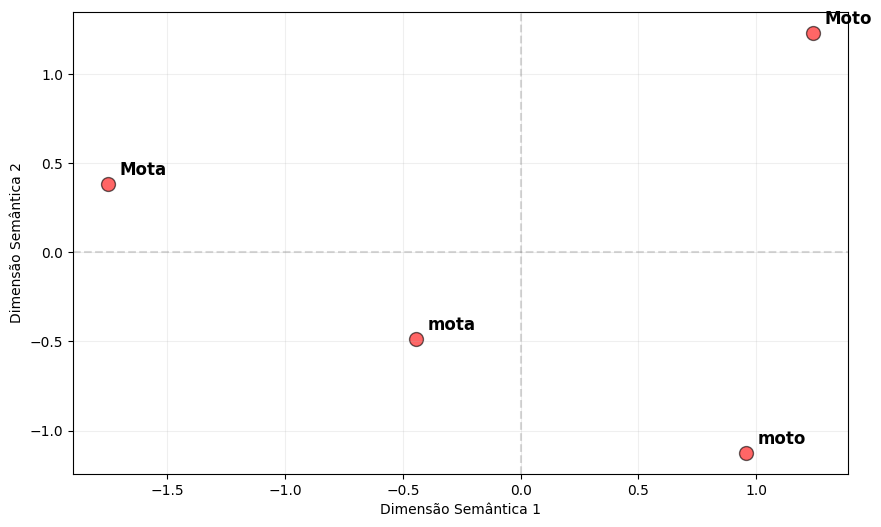

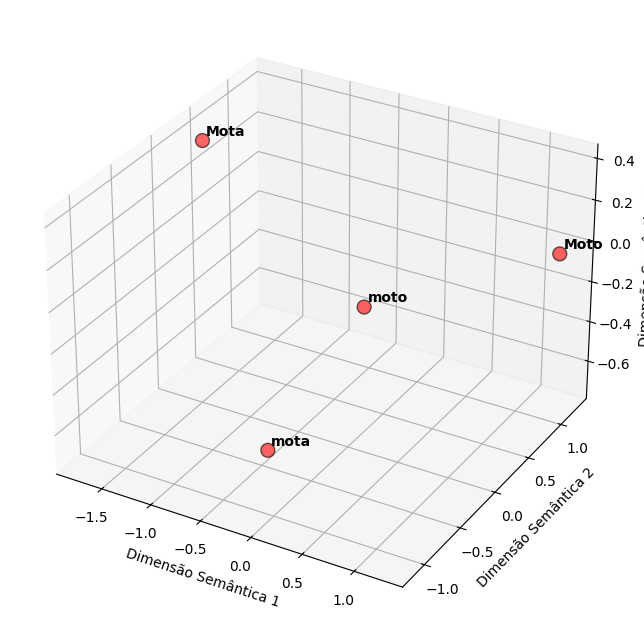

In [5]:
# redução de dimensionalidade (PCA) para 2 dimensões
palavras = ["mota", "moto", "Mota", "Moto"]

vetores = [texto_para_vetor(p) for p in palavras]

pca = PCA(n_components=2)
vetores_2d = pca.fit_transform(vetores)
plot2d(palavras, vetores_2d)

pca = PCA(n_components=3)
vetores_3d = pca.fit_transform(vetores)
plot3d(palavras, vetores_3d)

## 2. Comparando Vetores: Distância Semântica

Agora que temos vetores, podemos medir o quão similar uma palavra é de outra calculando a distância entre seus vetores.

In [6]:
palavra_base = "cachorro"
palavras = ["gato", "animal", "carro", "mesa"]

vetor_base = texto_para_vetor(palavra_base)
vetores = [texto_para_vetor(p) for p in palavras]

# Calcular a similaridade usando cosine similarity.Resultado de -1 a 1, onde 1  idêntico
similaridades = []
for vetor in vetores:
    sim = F.cosine_similarity(vetor_base.unsqueeze(0), vetor.unsqueeze(0)).item()
    similaridades.append(sim)

# Organizar em ordem de similaridade
resultados = list(zip(palavras, similaridades))
resultados.sort(key=lambda x: x[1], reverse=True)


print(f"Comparando '{palavra_base}':\n")
print_scores(resultados)

Comparando 'cachorro':

Palavra         Similaridade    Tipo
--------------------------------------------------
animal            0.791           Muito similar
carro             0.399           Diferente
gato              0.395           Diferente
mesa              0.309           Diferente


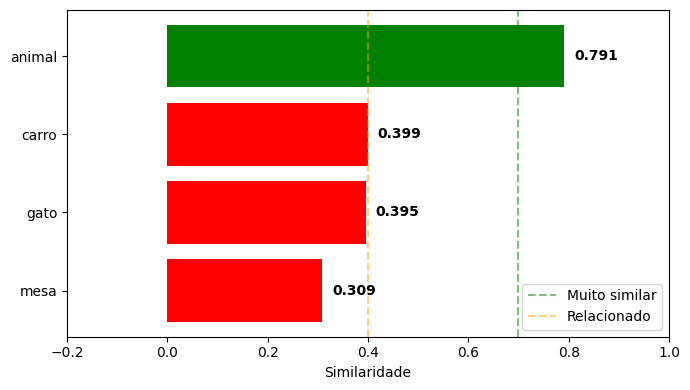

In [7]:
plot_scores(resultados)  

#### Resolvendo um dilema importante

In [8]:
palavras = ["mota", "moto", "motoca", "motota", "motinha", "carro", "veículo", "bicicleta", "caminhão"]

### Tentando ver esse treco em 2D usando PCA


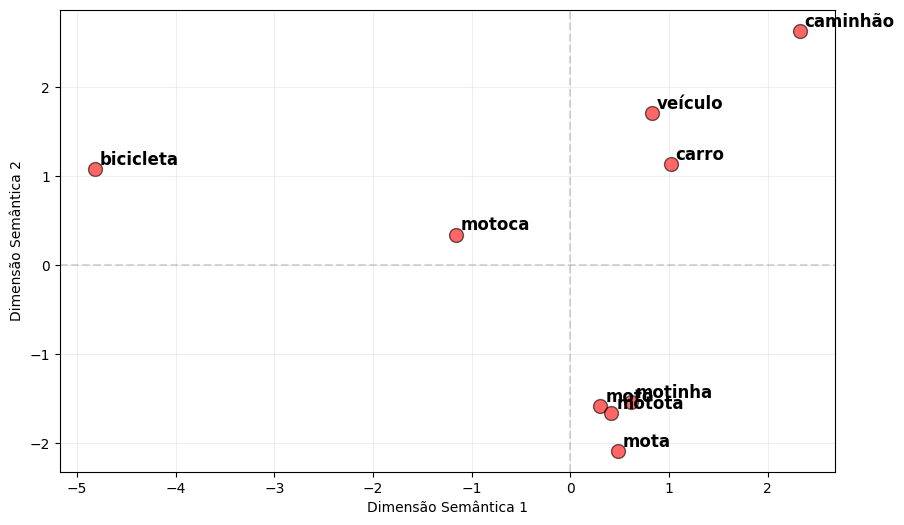

In [9]:
vetores = [texto_para_vetor(p).numpy() for p in palavras] 

# (PCA) para 2 dimensões
pca = PCA(n_components=2)
vetores_2d = pca.fit_transform(vetores)

plot2d(palavras, vetores_2d)

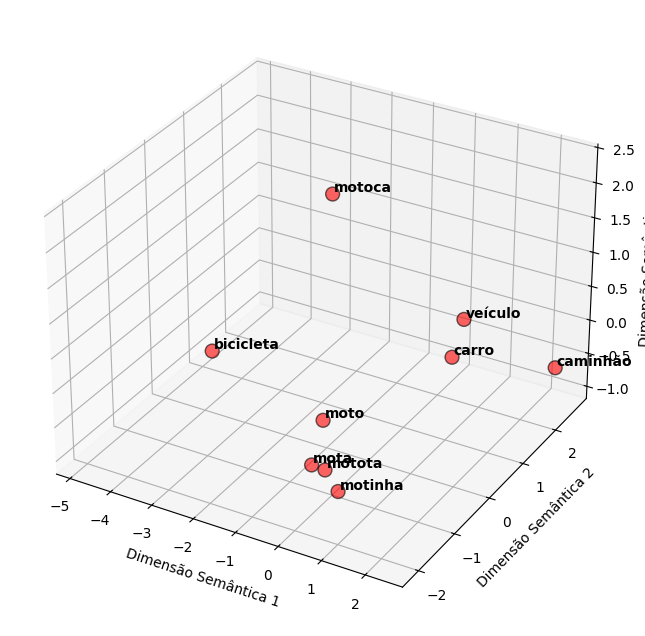

In [10]:
# 1. Redução de Dimensionalidade (PCA) para 3 dimensões
pca = PCA(n_components=3)
vetores_3d = pca.fit_transform(vetores)
plot3d(palavras, vetores_3d)

### E o tal do token?

In [11]:
frase_exemplo = "Palmeiras não tem mundial"

tokens = tokenizador.tokenize(frase_exemplo)
ids = tokenizador.encode(frase_exemplo, add_special_tokens=False)

print("Passo 1")
print(f"Tokens que o modelo enxerga: {tokens}")
print(f"IDs numéricos desses tokens: {ids}\n")
print(f"Temos um total de {len(tokens)} tokens nessa frase (+2, indicando começo e fim)\n")

Passo 1
Tokens que o modelo enxerga: ['▁Palm', 'eiras', '▁não', '▁tem', '▁mundial']
IDs numéricos desses tokens: [39287, 28610, 1027, 1790, 30597]

Temos um total de 5 tokens nessa frase (+2, indicando começo e fim)



In [12]:
entradas = tokenizador(frase_exemplo, return_tensors="pt")
with torch.no_grad(): # sem treino, irmão
    saida = modelo(**entradas)

# a mágica acontece aqui: pegamos o resultado bruto do modelo
vetores_brutos = saida.last_hidden_state
print("Passo 2 - um vetor para CADA token")
# vetores_brutos.shape nos diz o formato dessa matriz... exemplo: [1, 5, 384] = 1 frase, 5 tokens (vetores), 384 pontos em cada vetor
print(f"Formato (matriz) gerado pelo modelo: {vetores_brutos.shape}  \n")

Passo 2 - um vetor para CADA token
Formato (matriz) gerado pelo modelo: torch.Size([1, 7, 384])  



In [13]:
# a "fusão" em um vetor único (MEAN POOLING)
print("Passo 3 - média dos vetores: um vetor para a frase")
# Tiramos a média (mean) de todos os vetores da dimensão 1 (a dimensão dos tokens)
vetor_final = vetores_brutos.mean(dim=1)[0]

print(f"Formato do vetor final: {vetor_final.shape}")

Passo 3 - média dos vetores: um vetor para a frase
Formato do vetor final: torch.Size([384])


## 5. Diferentes Formas de Medir Distância

Existem várias formas de calcular a "distância" entre dois vetores. Cada uma tem vantagens e desvantagens.

In [14]:
# Vamos comparar dois textos usando diferentes métricas
texto_A = "gato"
texto_B = "felino"

vetor_A = texto_para_vetor(texto_A)
vetor_B = texto_para_vetor(texto_B)

print(f"Comparando '{texto_A}' vs '{texto_B}'\n")

# Cosine Similarity
cosine_sim = F.cosine_similarity(vetor_A.unsqueeze(0), vetor_B.unsqueeze(0)).item()
print(f"Cosine Similarity: {cosine_sim:.4f}")
print(f"  Escala: -1 (oposto) até 1 (idêntico)")
print(f"  Vantagem: ignora tamanho do vetor, só olha direção")
print(f"  Uso: quando a magnitude não importa\n")

# Euclidean Distance
euclidean = torch.dist(vetor_A, vetor_B).item()
print(f"Distância Euclidiana: {euclidean:.4f}")
print(f"  Escala: 0 (idêntico) para cima (muito diferente)")
print(f"  Vantagem: mais intuitivo, como distância real")
print(f"  Uso: quando a magnitude também importa\n")

# Manhattan Distance
manhattan = torch.norm(vetor_A - vetor_B, p=1).item()
print(f"Distância Manhattan: {manhattan:.4f}")
print(f"  Escala: 0 (idêntico) para cima (muito diferente)")
print(f"  Vantagem: computacionalmente mais rápido")
print(f"  Uso: quando precisa ser rápido e em larga escala")

Comparando 'gato' vs 'felino'

Cosine Similarity: 0.5173
  Escala: -1 (oposto) até 1 (idêntico)
  Vantagem: ignora tamanho do vetor, só olha direção
  Uso: quando a magnitude não importa

Distância Euclidiana: 4.6568
  Escala: 0 (idêntico) para cima (muito diferente)
  Vantagem: mais intuitivo, como distância real
  Uso: quando a magnitude também importa

Distância Manhattan: 71.4395
  Escala: 0 (idêntico) para cima (muito diferente)
  Vantagem: computacionalmente mais rápido
  Uso: quando precisa ser rápido e em larga escala


## 6. Agora: O Papel dos TOKENS

Até agora tratamos a entrada como "texto mágico que vira vetor". Mas o que acontece por baixo? Tokens.

Modelos não trabalham com texto diretamente. Primeiro convertem texto em tokens (pequenos pedaços), depois processam esses tokens.

O fluxo completo é:

```
Texto: "cachorro"
    ↓
Tokenização: ["ca", "chorro"]
    ↓
IDs numéricos: [123, 456]
    ↓
Modelo neural: processa cada ID
    ↓
Matriz de vetores: um vetor por token
    ↓
Agregação: tira a média
    ↓
Embedding final: [0.23, -0.45, 0.12, ...]
```

## 7. Vendo Tokens na Prática

Vamos ver exatamente como uma palavra é dividida em tokens.

In [15]:
# Vamos tokenizar alguns exemplos para entender o padrão

exemplos = [
    "cachorro",
    "cachorrinho",
    "COVID-19",
    "O gato preto"
]

print("Como diferentes textos são divididos em tokens:\n")

for texto in exemplos:
    # Pega os tokens em forma legível
    tokens = tokenizador.tokenize(texto)
    # Pega os IDs numéricos que o modelo usa internamente
    ids = tokenizador.encode(texto, add_special_tokens=True)
    
    print(f"Texto: '{texto}'")
    print(f"  Tokens: {tokens}")
    print(f"  IDs: {ids}")
    print(f"  Total: {len(tokens)} tokens\n")

print("\nObservações:")
print("- 'cachorro' é 1 token porque é uma palavra comum")
print("- 'cachorrinho' vira 2 partes (o sufixo -inho é separado)")
print("- 'COVID-19' vira 3 tokens (o hífen é separado)")
print("- Uma frase tem múltiplos tokens, um por palavra")

Como diferentes textos são divididos em tokens:

Texto: 'cachorro'
  Tokens: ['▁cachorro']
  IDs: [0, 209125, 2]
  Total: 1 tokens

Texto: 'cachorrinho'
  Tokens: ['▁ca', 'chor', 'rinho']
  IDs: [0, 377, 72988, 166684, 2]
  Total: 3 tokens

Texto: 'COVID-19'
  Tokens: ['▁CO', 'VID', '-19']
  IDs: [0, 8244, 74116, 8363, 2]
  Total: 3 tokens

Texto: 'O gato preto'
  Tokens: ['▁O', '▁gato', '▁preto']
  IDs: [0, 180, 125583, 17069, 2]
  Total: 3 tokens


Observações:
- 'cachorro' é 1 token porque é uma palavra comum
- 'cachorrinho' vira 2 partes (o sufixo -inho é separado)
- 'COVID-19' vira 3 tokens (o hífen é separado)
- Uma frase tem múltiplos tokens, um por palavra


## Como Tokenização Afeta o Embedding

A tokenização não é um detalhe menor. Ela afeta DIRETAMENTE o embedding final e portanto a similaridade que calculamos.

In [16]:
# Vamos ver como a tokenização impacta embeddings

palavras_teste = ["cat", "cats", "dog", "dogs"]

print("Como tokenização afeta o embedding:\n")

for palavra in palavras_teste:
    tokens = tokenizador.tokenize(palavra)
    embedding = texto_para_vetor(palavra)
    
    print(f"'{palavra}'")
    print(f"  Tokens: {tokens}")
    print(f"  Embedding (primeiros 5 números): {embedding[:5].tolist()}")
    print()

# Comparar similaridades
print("\nComparando similaridades:")
sim_cat_cats = F.cosine_similarity(texto_para_vetor("cat").unsqueeze(0), 
                                    texto_para_vetor("cats").unsqueeze(0)).item()
sim_cat_dog = F.cosine_similarity(texto_para_vetor("cat").unsqueeze(0), 
                                   texto_para_vetor("dog").unsqueeze(0)).item()

print(f"  'cat' vs 'cats': {sim_cat_cats:.4f} (muito similar - compartilham o radical)")
print(f"  'cat' vs 'dog': {sim_cat_dog:.4f} (bem menos similar - palavras diferentes)")
print()
print("Isso acontece porque 'cat' e 'cats' compartilham tokens.")
print("O modelo entende que eles são relacionados porque têm a mesma raiz.")

Como tokenização afeta o embedding:

'cat'
  Tokens: ['▁cat']
  Embedding (primeiros 5 números): [0.5905537605285645, -0.3334291875362396, -0.03257511556148529, 0.5430223345756531, -0.37234559655189514]

'cats'
  Tokens: ['▁cat', 's']
  Embedding (primeiros 5 números): [0.45276033878326416, -0.43281009793281555, -0.049548693001270294, 0.7045460939407349, -0.29738473892211914]

'dog'
  Tokens: ['▁dog']
  Embedding (primeiros 5 números): [0.2800450026988983, -0.24335874617099762, -0.2579025626182556, 0.1898757666349411, -0.20111151039600372]

'dogs'
  Tokens: ['▁dog', 's']
  Embedding (primeiros 5 números): [0.20116597414016724, -0.32987502217292786, -0.35556042194366455, 0.35330265760421753, -0.2013884037733078]


Comparando similaridades:
  'cat' vs 'cats': 0.9337 (muito similar - compartilham o radical)
  'cat' vs 'dog': 0.3033 (bem menos similar - palavras diferentes)

Isso acontece porque 'cat' e 'cats' compartilham tokens.
O modelo entende que eles são relacionados porque têm a mes

## 10. Resumo: A Conexão Completa

Agora você entende o caminho inteiro de como texto vira embedding:

1. Texto entra ("cachorro inteligente")
2. Tokenizador divide em tokens (["cach", "orro", "inteligente"])
3. Tokens viram IDs ([123, 456, 789])
4. Modelo neural processa cada ID e cria um vetor para cada um
5. Agregamos (geralmente tiramos a média) todos os vetores
6. Resultado: 1 vetor de 384 números (o embedding)
7. Usamos distância para comparar embeddings

Por que isso funciona:
- Tokens permitem o modelo entender texto novo que nunca viu
- Tokens criam relações ("gato" e "gatos" compartilham a raiz)
- Vetores capturam significado (o modelo foi treinado para isso)
- Similaridade de vetores revela semântica ("cachorro" é similar a "cão")

Aplicações práticas:
- Busca semântica: encontre documentos por significado, não por palavras
- RAG: recupere informação relevante para alimentar LLMs
- Classificação: agrupe textos similares automaticamente
- Chatbots: entenda a intenção real do usuário
- Recomendação: sugira conteúdo relacionado baseado em significado

## 11. Predição da Próxima Palavra

Até agora usamos embeddings para comparar significado (similaridade). Mas existe outro uso completamente diferente: usar o modelo para prever qual é a próxima palavra dada uma frase.

Isso não é mais sobre embeddings. É sobre Language Models - modelos treinados para gerar texto.

### A Diferença Entre Embeddings e Language Models

Você tem dois tipos principais de modelos:

1. **Modelos de Embedding** (que usamos até agora)
   - Entrada: um texto
   - Saída: um vetor que representa o significado
   - Treino: aprendem a comparar textos similares
   - Uso: busca, recomendação, RAG

2. **Language Models** (que vamos usar agora)
   - Entrada: um texto incompleto
   - Saída: uma distribuição de probabilidade para o próximo token
   - Treino: aprendem a prever o próximo token (predição)
   - Uso: geração de texto, chatbots, assistentes

São modelos relativamente diferentes com objetivos completamente diferentes!

In [17]:
from transformers import AutoTokenizer, AutoModelForCausalLM

# Carregar um modelo focado em gerar texto (Language Model)
nome_lm = "google/gemma-2-2b-it"
tokenizador_lm = AutoTokenizer.from_pretrained(nome_lm)
modelo_lm = AutoModelForCausalLM.from_pretrained(nome_lm)

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

In [18]:
frase_incompleta = "Palmeiras não"

print(f"Frase: '{frase_incompleta}' ... ?")

# Tokenizar
tokens = tokenizador_lm.encode(frase_incompleta, return_tensors="pt")

# Passar pelo modelo
with torch.no_grad():
    saida = modelo_lm(tokens)

# Pegar as probabilidades para o próximo token
# logits são as "notas brutas" antes de converter em probabilidade
logits_proximo = saida.logits[0, -1, :]

# Converter em probabilidades (0 a 1)
probabilidades = torch.softmax(logits_proximo, dim=-1)

# Pegar os top 5 candidatos mais prováveis
top_probs, top_ids = torch.topk(probabilidades, 5)

print("Top 5 tokens mais prováveis:\n")
print(f"{'Posição':<4} {'Palavra':<15} {'Probabilidade':<15}")
print("-" * 35)

for idx, (prob, token_id) in enumerate(zip(top_probs, top_ids), 1):
    palavra = tokenizador_lm.decode([token_id])
    percentual = prob.item() * 100
    barra = "█" * int(percentual / 5)
    print(f"{idx:<7} {palavra:<15} {percentual:>5.1f}% {barra}")

Frase: 'Palmeiras não' ... ?
Top 5 tokens mais prováveis:

Posição Palavra         Probabilidade  
-----------------------------------
1        conseguiu       16.3% ███
2        se              11.2% ██
3        vai              9.3% █
4        está             5.6% █
5        terá             5.0% 


### Como Isso Funciona Por Baixo

O modelo retorna um número para cada token possível do vocabulário. Esse número é chamado de "logit" (log-odds). Ele indica o quanto o modelo "acha" que aquele token é a próxima palavra.

Conversão:
1. Logits (valores brutos): [-2.3, 5.1, 0.2, ...]
2. Softmax (converte em probabilidade): [0.001, 0.95, 0.02, ...]
3. Selecionamos os tokens com maior probabilidade

Isso é exatamente como LLMs funcionam - eles geram texto um token por vez, sempre escolhendo (ou prevendo probabilisticamente) o próximo token.

In [19]:
frase = "Brasil foi campeao"

print(f"Começando com: '{frase}'\\n")

for i in range(5):  # Gerar 5 palavras
    # Tokenizar
    tokens = tokenizador_lm.encode(frase, return_tensors="pt")

    # Passar pelo modelo
    with torch.no_grad():
        saida = modelo_lm(tokens)

    # Pegar a próxima palavra mais provável
    logits_proximo = saida.logits[0, -1, :]
    token_proximo = torch.argmax(logits_proximo).item()

    # Decodificar para texto
    palavra_proxima = tokenizador_lm.decode([token_proximo])

    # Adicionar à frase
    frase += palavra_proxima

    print(f"Iteração {i+1}: '{frase}'")

print(f"Frase final: '{frase}'")
print("Note que o modelo gera token por token, sempre escolhendo o mais provável.")

Começando com: 'Brasil foi campeao'\n
Iteração 1: 'Brasil foi campeao da'
Iteração 2: 'Brasil foi campeao da Copa'
Iteração 3: 'Brasil foi campeao da Copa do'
Iteração 4: 'Brasil foi campeao da Copa do Mundo'
Iteração 5: 'Brasil foi campeao da Copa do Mundo de'
Frase final: 'Brasil foi campeao da Copa do Mundo de'
Note que o modelo gera token por token, sempre escolhendo o mais provável.


### Por Que Usamos Probabilidade?

Se sempre escolhéssemos o token mais provável (argmax), o modelo geraria sempre a mesma coisa. Seria determinístico e chato.

Na prática, modelos como ChatGPT fazem sampling: ao invés de pegar o mais provável, eles escolhem aleatoriamente entre as opções, pesando pelas probabilidades.

Por exemplo, se as probabilidades fossem:
- "throne": 35%
- "bed": 30%
- "horse": 25%
- outros: 10%

O modelo pode escolher qualquer um desses, mas "throne" tem 35% de chance, "bed" tem 30%, etc.

Isso cria respostas variadas e mais naturais!

In [20]:
# Simulando sampling com temperatura

def gerar_com_sampling(frase_inicial, num_tokens=10, temperatura=1.0):
    frase = frase_inicial

    for _ in range(num_tokens):
        tokens = tokenizador_lm.encode(frase, return_tensors="pt")

        with torch.no_grad():
            saida = modelo_lm(tokens)

        logits_proximo = saida.logits[0, -1, :]

        # A temperatura controla o quão "criativo" o modelo é
        # temperatura baixa = mais determinístico
        # temperatura alta = mais aleatório
        logits_ajustado = logits_proximo / temperatura

        # Converter em probabilidades
        probs = torch.softmax(logits_ajustado, dim=-1)

        # Fazer sampling (escolher aleatoriamente baseado nas probabilidades)
        token_proximo = torch.multinomial(probs, 1).item()

        palavra = tokenizador_lm.decode([token_proximo])
        frase += palavra

    return frase

# Testar com diferentes temperaturas
frase_inicial = "Palmeiras não"

print(f"Frase inicial: '{frase_inicial}'\n")

print("Com temperatura 0.5 (mais conservador):")
resultado1 = gerar_com_sampling(frase_inicial, temperatura=0.5)
print(f"  {resultado1}\n")

print("Com temperatura 1.0 (balanceado):")
resultado2 = gerar_com_sampling(frase_inicial, temperatura=1.0)
print(f"  {resultado2}\n")

print("Com temperatura 2.0 (mais criativo/aleatório):")
resultado3 = gerar_com_sampling(frase_inicial, temperatura=2.0)
print(f"  {resultado3}")

Frase inicial: 'Palmeiras não'

Com temperatura 0.5 (mais conservador):
  Palmeiras não terá mais o goleiro Marcos, que foi transfer

Com temperatura 1.0 (balanceado):
  Palmeiras não abre mão de seu futebol de ataque. O Verd

Com temperatura 2.0 (mais criativo/aleatório):
  Palmeiras não conseguiu con inquietração num empate HowellДмитрий振り返 RSI


### Conectando Com Tudo Que Aprendemos

Agora vamos voltar ao começo e entender a relação entre tudo:

1. **Embeddings** (primeira parte do notebook)
   - Transformam texto em vetor
   - Permitem comparar significado
   - Usam tokens internamente

2. **Language Models** (esta parte)
   - Também processam tokens
   - Mas em vez de gerar um vetor, geram probabilidades para o próximo token
   - Essas probabilidades permitem gerar novo texto

3. **Tokens** (o elo de ligação)
   - Todos os modelos usam tokens
   - Tokens são o "meio comum" entre diferentes tipos de modelos
   - Você não passa texto bruto para o modelo, passa IDs de tokens

4. **LLMs** (o passo adiante)
   - ChatGPT, Claude, Llama, etc. são language models
   - Eles fazem exatamente o que vimos aqui: preveem o próximo token
   - Mas com modelos muito maiores e treinamento mais sofisticado
   - Mesmo assim, o princípio é exatamente o mesmo: dado um contexto, qual é o próximo token mais provável?

Você agora entende como texto é processado em redes neurais modernas!